In [2]:
!git clone https://github.com/sravanya-2006/space-weather-ai-guardian.git

Cloning into 'space-weather-ai-guardian'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 17 (delta 1), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 58.56 KiB | 1.25 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
%cd space-weather-ai-guardian
!ls

/content/space-weather-ai-guardian
data  LICENSE  notebooks  README.md  requirements.txt  src  test.py


In [4]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.8 MB/s eta 0:00:00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("data/raw/solar_flares.csv")

In [8]:
df.head()

,flrID,catalog,instruments,beginTime,peakTime,endTime,classType,sourceLocation,activeRegionNum,note,submissionTime,versionId,link,linkedEvents,sentNotifications
0,2024-01-01T08:33:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-01T08:33Z,2024-01-01T08:54Z,2024-01-01T09:04Z,M2.3,N03E70,13536.0,NaN,2024-01-01T13:28Z,1,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,NaN,NaN
1,2024-01-01T11:54:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-01T11:54Z,2024-01-01T12:25Z,2024-01-01T12:35Z,M4.7,N03E68,13536.0,NaN,2024-01-01T13:24Z,1,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,NaN,NaN
2,2024-01-02T18:02:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-02T18:02Z,2024-01-02T18:30Z,2024-01-02T18:56Z,M1.1,N05E59,13536.0,NaN,2024-01-02T19:34Z,2,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,[{'activityID': '2024-01-02T19:36:00-CME-001'}],NaN
3,2024-01-04T01:08:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-04T01:08Z,2024-01-04T01:16Z,2024-01-04T01:22Z,M1.1,N02E38,13536.0,NaN,2024-01-04T01:44Z,1,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,NaN,NaN
4,2024-01-04T01:22:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-04T01:22Z,2024-01-04T01:55Z,2024-01-04T02:12Z,M3.8,N04E38,13536.0,NaN,2024-01-04T03:00Z,1,https://webtools.ccmc.gsfc.nasa.gov/DONKI/view...,NaN,NaN


In [9]:
df.shape

(1128, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   flrID              1128 non-null   object 
 1   catalog            1128 non-null   object 
 2   instruments        1128 non-null   object 
 3   beginTime          1128 non-null   object 
 4   peakTime           1128 non-null   object 
 5   endTime            1128 non-null   object 
 6   classType          1128 non-null   object 
 7   sourceLocation     1128 non-null   object 
 8   activeRegionNum    1102 non-null   float64
 9   note               299 non-null    object 
 10  submissionTime     1128 non-null   object 
 11  versionId          1128 non-null   int64  
 12  link               1128 non-null   object 
 13  linkedEvents       324 non-null    object 
 14  sentNotifications  136 non-null    object 
dtypes: float64(1), int64(1), object(13)
memory usage: 132.3+ KB


In [11]:
df.isnull().sum()

,0
flrID,0
catalog,0
instruments,0
beginTime,0
peakTime,0
endTime,0
classType,0
sourceLocation,0
activeRegionNum,26
note,829


In [12]:
df.columns.tolist()

['flrID',
 'catalog',
 'instruments',
 'beginTime',
 'peakTime',
 'endTime',
 'classType',
 'sourceLocation',
 'activeRegionNum',
 'note',
 'submissionTime',
 'versionId',
 'link',
 'linkedEvents',
 'sentNotifications']

In [13]:
df["classType"].value_counts()

,count
classType,
M1.0,132
M1.1,93
M1.2,89
M1.3,75
M1.4,57
...,...
C2.8,1
C3.7,1
C7.2,1


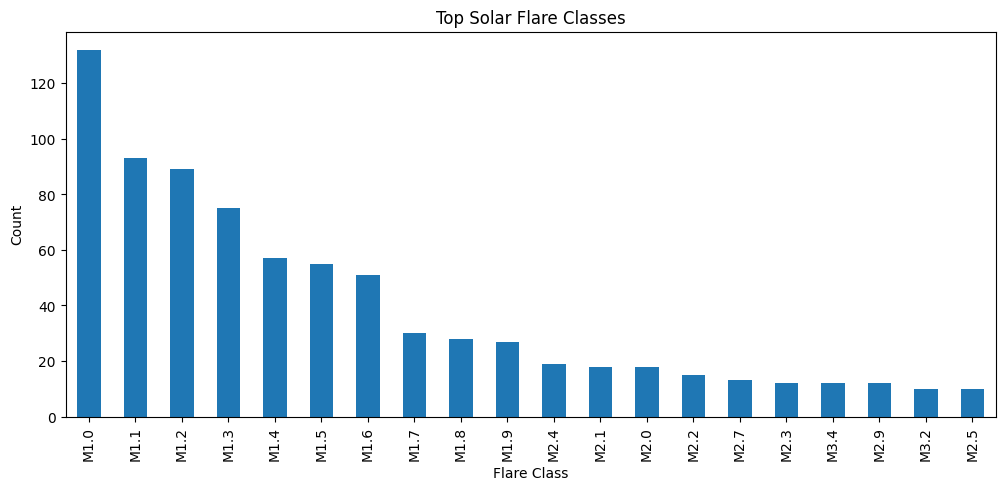

In [14]:
plt.figure(figsize=(12,5))

df["classType"].value_counts().head(20).plot(kind="bar")

plt.title("Top Solar Flare Classes")
plt.xlabel("Flare Class")
plt.ylabel("Count")

plt.show()

In [15]:
df[["beginTime","peakTime","endTime"]].head()

,beginTime,peakTime,endTime
0,2024-01-01T08:33Z,2024-01-01T08:54Z,2024-01-01T09:04Z
1,2024-01-01T11:54Z,2024-01-01T12:25Z,2024-01-01T12:35Z
2,2024-01-02T18:02Z,2024-01-02T18:30Z,2024-01-02T18:56Z
3,2024-01-04T01:08Z,2024-01-04T01:16Z,2024-01-04T01:22Z
4,2024-01-04T01:22Z,2024-01-04T01:55Z,2024-01-04T02:12Z
